# Does dealer positioning inferred from public SDR prints predict SR3 / ZQ?

**This notebook renders; it does not compute.** The gates are run by
`scripts/run_dealer_ladder_gates.py`, which writes every artifact to
`BT/results/dealer_ladder/*.csv`. That split is the repo convention and it is what makes an
*executed* notebook a reviewable artifact instead of a multi-hour job nobody re-runs.

- Pre-registration and verdict: `docs/superpowers/plans/2026-07-30-dealer-ladder-signal-findings.md`
- Running journal (decisions, timings, constraints): `docs/superpowers/plans/2026-07-29-dealer-ladder-research-journal.md`

**Read the gates in order.** G2 (does the ladder lead measurable futures flow?) runs before any
price test, because a price result whose mechanism was never established is a different and much
weaker claim. A failed gate is a result, reported as such.

**What this is not.** The direction label is a model inference from price-versus-curve-mid, not an
observed counterparty field, and it is uncertified against truth labels — no desk tickets were
available. Every signed number therefore carries the `(2a-1)` attenuation grid, and the object is
described throughout as a *model-labelled D2C flow proxy*, never as dealer inventory.

In [1]:
import os
import sys

import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

from BT.dealer_ladder import plots

plots.use_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 120)

# Overridable so this notebook can be executed against a fixture directory as a
# pre-flight check -- a cell that raises on real results is a failed run discovered at
# the worst moment, and the fixture pass costs seconds.
RESULTS = os.environ.get("DEALER_LADDER_RESULTS") or os.path.abspath(
    os.path.join(os.getcwd(), "..", "..", "BT", "results", "dealer_ladder"))


def load(name, **kw):
    """Read a gate artifact, or return an empty frame so a missing stage cannot
    silently look like a passing one."""
    path = os.path.join(RESULTS, f"{name}.csv")
    if not os.path.exists(path):
        print(f"  [missing] {name}.csv — that stage did not produce output")
        return pd.DataFrame()
    return pd.read_csv(path, **kw)


print(f"results dir: {RESULTS}")
print(sorted(os.listdir(RESULTS)) if os.path.isdir(RESULTS) else "  (does not exist yet)")

results dir: C:/Users/chris/clee/ARBS-ladder/BT/results/dealer_ladder
['g0_exclusion_ladder.csv', 'g0_flip_by_confidence.csv', 'g0_flip_by_curve_bucket.csv', 'g0_flip_by_hour.csv', 'g0_flip_by_trade_type.csv', 'g0_flip_mechanism.csv', 'g0_implied_accuracy.csv', 'g0_label_recon.csv', 'g0_mid_offset_bps.csv', 'g0_pflip_calibration.csv', 'g0_skew_by_stratum.csv', 'g0_skew_vs_independent.csv', 'g0_skew_vs_independent_by_hour.csv', 'g0_universe_summary.csv', 'g1_audits.csv', 'g2_cross_check.csv', 'g2_flow_events_FED_FUNDS.csv', 'g2_flow_events_FUTURES.csv', 'g2_flow_response_FED_FUNDS.csv', 'g2_flow_response_FUTURES.csv', 'g2_lead_lag_FED_FUNDS.csv', 'g2_lead_lag_FUTURES.csv', 'g2_lead_lag_summary_FED_FUNDS.csv', 'g2_lead_lag_summary_FUTURES.csv', 'g2_peak_rho_summary_FED_FUNDS.csv', 'g2_peak_rho_summary_FUTURES.csv', 'g3_horse_race_FED_FUNDS.csv', 'g3_horse_race_FUTURES.csv', 'g3_horse_race_independent_FUTURES.csv', 'g3_leave_one_out_FED_FUNDS.csv', 'g3_leave_one_out_FUTURES.csv', 'g3_poin

## Verdict summary

State is shown as **text** beside the swatch, never as colour alone.

,gate,pass,headline
0,G0,NaN,signed universe 28704 units; 1 code vintage(s)...
1,G1,True,"all arrival audits pass, poison audit exercise..."
2,G2,False,"LLS mean=-4.769 t=-2.45*, mean peak rho=-0.035..."
3,G3,False,"signal t alone=0.14, vs our controls=0.50 (coe..."
4,G2,False,"LLS mean=-19.88 t=-1.78., mean peak rho=-0.005..."
5,G3,False,"signal t alone=-1.47, vs our controls=-1.19 (c..."
6,G2-cross-check,NaN,leads NEITHER -> no mechanism evidence from th...
7,G4-primary(in-sample),False,"net -0.5458bp/trade, t=-9.44***, n=1639 trades..."
8,label-free,NaN,"unsigned intensity: net -0.6402bp, t=-9.03***,..."
9,conditioning,NaN,6/6 conditioners sign-consistent across tercil...


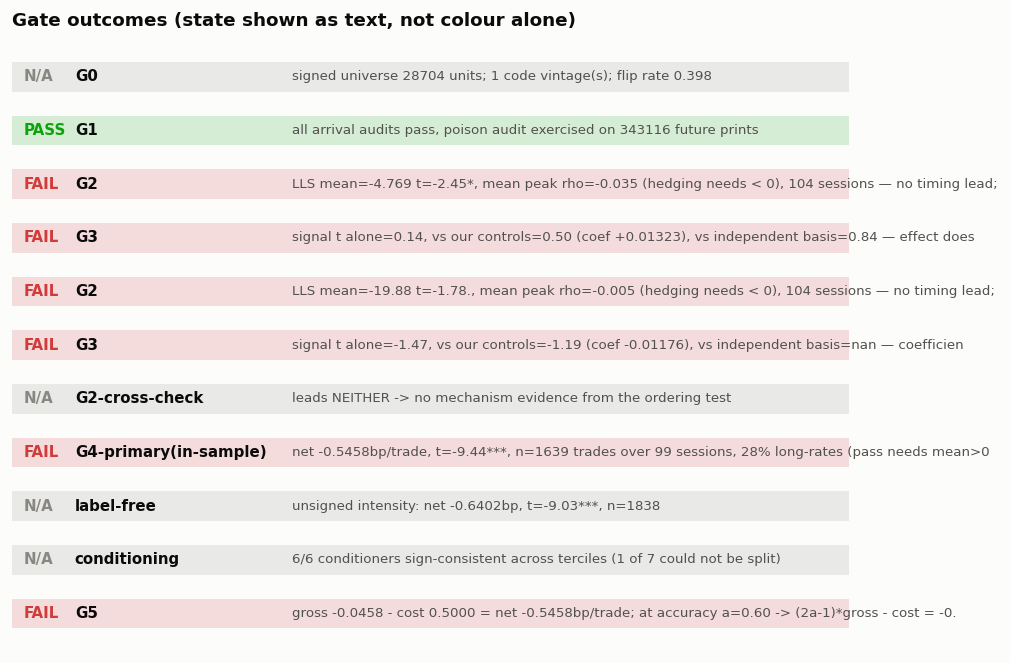

In [2]:
verdicts = load("verdicts")
if len(verdicts):
    display(verdicts[[c for c in ("gate", "pass", "headline") if c in verdicts.columns]])
    plots.verdict_strip(verdicts.to_dict(orient="records"))
else:
    print("no verdicts yet — run scripts/run_dealer_ladder_gates.py")

## G0 — labels and provenance

Which prints are in the signed universe, which gate removed the rest, and does an **independent
mid** agree with the direction call? The independent mid is the Citi Velocity intraday SOFR par
curve, run through the *identical* classifier, so a flip isolates curve disagreement rather than
a difference in rule. Both independent sources are SOFR curves, so FED_FUNDS has no cross-check.

In [3]:
summary = load("g0_universe_summary", index_col=0)
ladder_tbl = load("g0_exclusion_ladder", index_col=0)
skew = load("g0_skew_by_stratum", index_col=0)
for name, frame in (("universe", summary), ("exclusion ladder", ladder_tbl),
                    ("skew by stratum", skew)):
    if len(frame):
        print(f"-- {name}")
        display(frame)

-- universe


,n_units_all,n_units_signed,paid_share_signed,p_flip_coverage_signed,n_code_vintages
0,84201,28704,0.771147,0.925969,1


-- exclusion ladder


,step,units,removed
0,start: all projected prints,84201,0
1,direction in PAID/RECEIVED,84201,0
2,classification method in universe,53543,30658
3,TICK_RULE excluded,53543,0
4,curve-clean only,32719,20824
5,whitelisted D2C venue only,28704,4015
6,single code vintage,28704,0


-- skew by stratum


,venue_bucket,curve_bucket,market_bucket,n,paid_share,p_flip_share
0,D2C_WHITELISTED,CURVE_CLEAN,OFF_MARKET,8449,0.748846,1.000000
1,D2C_WHITELISTED,CURVE_CLEAN,ON_MARKET,38497,0.694937,0.690417
2,D2C_WHITELISTED,CURVE_SUSPECT,OFF_MARKET,10187,0.650437,0.000000
3,D2C_WHITELISTED,CURVE_SUSPECT,ON_MARKET,18166,0.791919,0.000000
4,VENUE_UNKNOWN,CURVE_CLEAN,OFF_MARKET,325,0.720000,1.000000
5,VENUE_UNKNOWN,CURVE_CLEAN,ON_MARKET,5398,0.695072,0.694702
6,VENUE_UNKNOWN,CURVE_SUSPECT,OFF_MARKET,521,0.558541,0.000000
7,VENUE_UNKNOWN,CURVE_SUSPECT,ON_MARKET,2658,0.713318,0.000000


,our_confidence,n_units,n_compared,flip_rate,n_no_coverage
0,HIGH,2398,2049,0.386042,349
1,LOW,2547,2191,0.334094,356
2,MEDIUM,575,483,0.451346,92


,trade_type,n_units,n_compared,flip_rate,n_no_coverage
0,CURVE,277,227,0.378855,50
1,FLY,54,38,0.342105,16
2,OUTRIGHT,5189,4458,0.368327,731


-- PAID share: our mid vs the independent mid, same prints


,index,n,our_paid_share,ind_paid_share,flip_rate
0,ALL,4723.0,0.797798,0.566377,0.368622


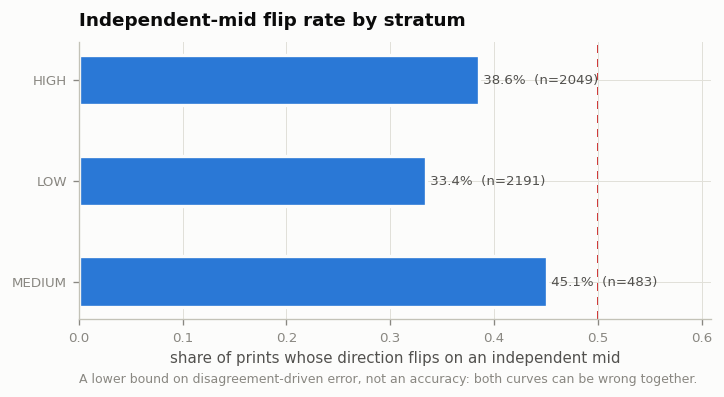

In [4]:
flip_conf = load("g0_flip_by_confidence", index_col=0)
flip_type = load("g0_flip_by_trade_type", index_col=0)
skew_ind = load("g0_skew_vs_independent", index_col=0)
if len(flip_conf):
    display(flip_conf)
    plots.flip_rate_bars(flip_conf, group="our_confidence")
if len(flip_type):
    display(flip_type)
if len(skew_ind):
    print("-- PAID share: our mid vs the independent mid, same prints")
    display(skew_ind)

## G1 — arrival integrity

Verified by **differential audit**, not assertion: corrupt every not-yet-visible print and check
the feature does not move. `n_leaking` must be 0 and `max_future_prints` must be > 0 — otherwise
the audit passed vacuously because there was nothing to poison. If this gate fails, everything
downstream is void.

In [5]:
g1 = load("g1_audits", index_col=0)
if len(g1):
    display(g1)
    if not bool(g1["pass"].all()):
        print("\n  *** LOOK-AHEAD DETECTED — the gates below are not interpretable ***")

,audit,pass,n,mode,observed_delays,illegal_delays,n_shorter_than_minimum,n_timestamps,n_leaking,min_future_prints,max_future_prints,leaks,split_at,max_abs_dev_in_head
0,visibility_delays,True,344448.0,delay-set-only,"[1.0, 15.0, 30.0, 60.0]",[],0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,future_poison,True,NaN,NaN,NaN,NaN,NaN,200.0,0.0,876.0,343116.0,[],NaN,NaN
2,trailing_moments,True,13248.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6624.0,0.0


## G2 — mechanism ordering (runs before any price test)

Does a signed ladder innovation *precede* measurable signed futures flow? Signed flow is a
**bar-direction** proxy, not Lee-Ready: there is no trade-level data in the repo, only quote
updates. ~39% of SR3 bars close unchanged and contribute zero signed volume, which biases the
measured lead-lag toward zero — the proxy is conservative.

The hypothesised hedge is a **sale** when the ladder is positive (a dealer long
futures-equivalent must sell), so the flow response is expected **opposite** in sign to the
innovation. That is carried explicitly in the `expected_sign` column.

In [6]:
ll_sum = load("g2_lead_lag_summary_FUTURES", index_col=0)
ll = load("g2_lead_lag_FUTURES", index_col=0)
flow_resp = load("g2_flow_response_FUTURES", index_col=0)
if len(ll_sum):
    print("-- ladder-leads-flow, day-blocked")
    display(ll_sum)
if len(ll):
    print(f"-- per (session, bucket) rows: {len(ll)}")
    display(ll.head(10))
    by_bucket = ll.groupby("bucket")[["lls", "peak_lag_min", "peak_rho"]].mean()
    display(by_bucket)
if len(flow_resp):
    print("-- signed flow response after a large ladder innovation")
    display(flow_resp)

rho = load("g2_peak_rho_summary_FUTURES", index_col=0)
if len(rho):
    print("-- signed peak correlation (LLS is direction-BLIND; this is the direction)")
    display(rho)
    m = float(rho["mean"].iloc[0])
    print(f"  mean peak rho {m:+.4f} -- hedging requires NEGATIVE "
          f"(a positive ladder means the dealer must SELL)")
    if m > 0:
        print("  -> a lead in this direction REFUTES the forced-hedge channel; it does "
              "not support it")


-- ladder-leads-flow, day-blocked


,mean,se,t,n,n_blocks,stars,share_agreeing,p_sign
0,-4.768886,1.949727,-2.445924,624,104,*,0.673077,0.000534


-- per (session, bucket) rows: 624


,day,bucket,lls,peak_lag_min,peak_rho,n_x,n_y
0,0,SFRH26,-17.634773,-15.0,-0.213367,96,95
1,0,SFRM26,-0.526979,-15.0,0.180410,96,95
2,0,SFRU26,-2.029028,-1.0,0.212213,96,95
3,0,SFRZ26,2.683991,240.0,-0.163968,96,95
4,0,SFRH27,-2.084896,-15.0,0.351519,96,95
5,0,SFRM27,-6.387562,-15.0,0.354967,96,95
6,1,SFRH26,-0.819480,-60.0,-0.223025,96,96
7,1,SFRM26,-2.749880,-60.0,-0.262815,96,96
8,1,SFRU26,-0.400020,-60.0,-0.081334,96,96
9,1,SFRZ26,-3.555837,-1.0,0.302454,96,96


,lls,peak_lag_min,peak_rho
bucket,,,
SFRH26,-4.117315,-10.222222,-0.060614
SFRH27,-2.810901,-19.500000,-0.043177
SFRM26,-1.932861,-12.730769,-0.058307
SFRM27,-0.701776,-20.711538,0.009166
SFRU26,-14.324956,-14.836538,-0.046902
SFRU27,-0.225292,-1.101695,0.009977
SFRZ26,-6.933479,-14.153846,-0.048144


-- signed flow response after a large ladder innovation


,horizon_min,mean,se,t,n,n_blocks,stars,expected_sign
0,5,9.386730,85.150023,0.110238,5893,104,NaN,-1
1,15,-167.300865,116.882041,-1.431365,5893,104,NaN,-1
2,30,-266.658408,149.525766,-1.783361,5893,104,.,-1
3,60,-234.117767,226.059351,-1.035647,5893,104,NaN,-1


-- signed peak correlation (LLS is direction-BLIND; this is the direction)


,mean,se,t,n,n_blocks,stars
0,-0.034655,0.012798,-2.707948,624,104,**


  mean peak rho -0.0347 -- hedging requires NEGATIVE (a positive ladder means the dealer must SELL)


## G2 cross-check — SR3 versus ZQ

The brief makes this the comparison the **mechanism** turns on, and the two readings point at
different desks:

- **leads SR3 but not ZQ** → liquidity-routed hedging: the dealer hedges where the depth is, which
  is the SOFR strip, regardless of where the risk actually sits;
- **leads ZQ specifically** → meeting-targeted: the exposure is about policy dates and is hedged in
  the contract that isolates them;
- **leads both** → undiscriminating. Consistent with either, so it contributes nothing and must not
  be quoted as though it did;
- **leads neither** → no mechanism evidence from the ordering test at all.

The reading is computed in `gates.run_cross_check_comparison` rather than left to be inferred from
two tables side by side, which is where a preferred reading gets chosen.

In [7]:
cross = load("g2_cross_check", index_col=0)
if len(cross):
    display(cross)
    print("  " + str(cross["reading"].iloc[0]))
else:
    print("no cross-check artifact -- G2 did not run for both spaces")

print()
for name in ("g2_lead_lag_summary_FED_FUNDS", "g2_peak_rho_summary_FED_FUNDS",
             "g2_flow_response_FED_FUNDS"):
    frame = load(name, index_col=0)
    if len(frame):
        print(f"-- {name}")
        display(frame)

# The raw per-event and per-(day, bucket) frames -- g2_flow_events_*,
# g2_lead_lag_* -- run to thousands of rows and are deliberately NOT rendered
# here; their SUMMARIES are above, and the full frames appear in the generated
# tables of the findings doc. Omitted on purpose, not by oversight.


,space,root,lls_mean,lls_t,peak_rho_mean,peak_rho_t,timing_lead,direction_ok,leads,reading
0,FUTURES,SR3,-4.768886,-2.445924,-0.034655,-2.707948,False,True,False,leads NEITHER -> no mechanism evidence from th...
1,FED_FUNDS,ZQ,-19.875217,-1.778364,-0.004810,-0.372176,False,True,False,leads NEITHER -> no mechanism evidence from th...


  leads NEITHER -> no mechanism evidence from the ordering test

-- g2_lead_lag_summary_FED_FUNDS


,mean,se,t,n,n_blocks,stars,share_agreeing,p_sign
0,-19.875217,11.176123,-1.778364,624,104,.,0.663462,0.001109


-- g2_peak_rho_summary_FED_FUNDS


,mean,se,t,n,n_blocks,stars
0,-0.00481,0.012925,-0.372176,624,104,NaN


-- g2_flow_response_FED_FUNDS


,horizon_min,mean,se,t,n,n_blocks,stars,expected_sign
0,5,19.420474,31.769158,0.611300,5910,104,NaN,-1
1,15,-44.265144,21.868634,-2.024139,5910,104,*,-1
2,30,-59.541963,41.187204,-1.445642,5910,104,NaN,-1
3,60,-37.634349,52.798611,-0.712791,5910,104,NaN,-1


### G3 on ZQ — does the cross-check survive its own controls?

Reported for symmetry with SR3. ZQ is a **cross-check, never a test target**: the pre-registered
primary is SR3 front-six, and nothing here can promote a ZQ result into a headline.

In [8]:
for name in ("g3_horse_race_FED_FUNDS", "g3_horse_race_independent_FED_FUNDS",
             "g3_point_in_time_FED_FUNDS", "g3_leave_one_out_FED_FUNDS",
             "g3_residual_race_FED_FUNDS"):
    frame = load(name, index_col=0)
    if len(frame):
        print(f"-- {name}")
        display(frame)

-- g3_horse_race_FED_FUNDS


,spec,term,coef,se,t,n,n_blocks,design_rank,design_cols,design_cond,rank_deficient
0,signal only,const,2.119266e-02,2.037175e-02,1.040296,16090,99,2,2,1.435537e+00,False
1,signal only,signal,-1.221186e-02,8.280409e-03,-1.474789,16090,99,2,2,1.435537e+00,False
2,signal + controls,const,6.398757e+00,3.727457e-03,1716.654958,16090,99,14,14,3.232955e+07,False
3,signal + controls,signal,-1.175949e-02,9.903329e-03,-1.187428,16090,99,14,14,3.232955e+07,False
4,signal + controls,basis_bp,1.332463e-02,1.621521e-02,0.821737,16090,99,14,14,3.232955e+07,False
5,signal + controls,abs_basis_bp,-2.172433e-02,2.062838e-02,-1.053129,16090,99,14,14,3.232955e+07,False
6,signal + controls,signed_basis_dv01,1.534524e-07,2.376194e-07,0.645791,16090,99,14,14,3.232955e+07,False
7,signal + controls,level_bp,-1.736024e-02,4.371575e-04,-39.711642,16090,99,14,14,3.232955e+07,False
8,signal + controls,slope_bp,1.399900e-03,7.249198e-03,0.193111,16090,99,14,14,3.232955e+07,False
9,signal + controls,curvature_bp,-8.317948e-03,9.996374e-03,-0.832096,16090,99,14,14,3.232955e+07,False


  [missing] g3_horse_race_independent_FED_FUNDS.csv — that stage did not produce output
-- g3_point_in_time_FED_FUNDS


,curve,rows_dropped_future_stamp,drop_rate,rows_unverifiable_stamp,unverifiable_rate
0,decision_curve,0.0,0.0,0.0,0.0


-- g3_leave_one_out_FED_FUNDS


,held_out,mean_bp,t,n
0,FFF26,-0.009132,-1.049523,41258
1,FFG26,-0.009289,-1.037032,40047
2,FFH26,-0.009659,-1.046496,38486
3,FFJ26,-0.011390,-1.186098,36809
4,FFK26,-0.011306,-1.108219,35335
5,FFM26,-0.011644,-1.236094,34759
6,FFN26,-0.004590,-0.501886,34749
7,FFQ26,-0.006185,-0.835881,36057
8,FFU26,-0.007621,-1.016389,37986
9,FFV26,-0.009278,-1.087111,39502


-- g3_residual_race_FED_FUNDS


,spec,term,coef,se,t,n,n_blocks,design_rank,design_cols,design_cond,rank_deficient
0,signal only,const,0.021364,0.020353,1.049674,16090,99,2,2,1.282616,False
1,signal only,signal,-0.011759,0.009882,-1.189976,16090,99,2,2,1.282616,False
2,signal + controls,const,0.021364,0.020353,1.049674,16090,99,2,2,1.282616,False
3,signal + controls,signal,-0.011759,0.009882,-1.189976,16090,99,2,2,1.282616,False


## G3 — circularity battery

The ladder is built on a curve calibrated from the same futures strip the study tries to predict,
so the question is not whether the signal is significant alone but whether it **survives** the
basis, curve shape, momentum, volatility, liquidity, time of day, roll and FOMC proximity. If the
coefficient collapses beside those controls, the effect lives in the basis and the thesis is a
different one.

In [9]:
race = load("g3_horse_race_FUTURES", index_col=0)
loo = load("g3_leave_one_out_FUTURES", index_col=0)
resid = load("g3_residual_race_FUTURES", index_col=0)
if len(race):
    print("-- horse race (day-clustered errors)")
    display(race)
if len(loo):
    print("-- leave one contract out: a result that needs one contract is one contract's story")
    display(loo)
if len(resid):
    print("-- residualised signal (orthogonalised to the controls)")
    display(resid)

-- horse race (day-clustered errors)


,spec,term,coef,se,t,n,n_blocks,design_rank,design_cols,design_cond,rank_deficient
0,signal only,const,9.459667e-03,4.429126e-02,0.213579,42426,99,2,2,1.344130e+00,False
1,signal only,signal,3.463498e-03,2.473299e-02,0.140036,42426,99,2,2,1.344130e+00,False
2,signal + controls,const,2.244719e+01,1.609689e+01,1.394504,42426,99,14,14,2.800506e+08,False
3,signal + controls,signal,1.323385e-02,2.630664e-02,0.503061,42426,99,14,14,2.800506e+08,False
4,signal + controls,basis_bp,4.735488e-02,2.342736e-02,2.021350,42426,99,14,14,2.800506e+08,False
5,signal + controls,abs_basis_bp,-3.284222e-02,2.104008e-02,-1.560936,42426,99,14,14,2.800506e+08,False
6,signal + controls,signed_basis_dv01,3.188123e-07,1.865699e-07,1.708809,42426,99,14,14,2.800506e+08,False
7,signal + controls,level_bp,-6.022857e-02,4.394490e-02,-1.370547,42426,99,14,14,2.800506e+08,False
8,signal + controls,slope_bp,3.201309e-02,2.303802e-02,1.389576,42426,99,14,14,2.800506e+08,False
9,signal + controls,curvature_bp,2.532923e-02,1.730210e-02,1.463940,42426,99,14,14,2.800506e+08,False


-- leave one contract out: a result that needs one contract is one contract's story


,held_out,mean_bp,t,n
0,SFRH26,0.035806,1.052034,46194
1,SFRH27,0.030131,1.069678,41295
2,SFRM26,0.038703,1.060136,41295
3,SFRM27,0.032359,1.070434,41295
4,SFRU26,0.033521,0.995364,41295
5,SFRU27,0.028390,0.906124,44655
6,SFRZ26,0.031547,1.017452,41295
7,<none>,0.032919,1.037125,49554


-- residualised signal (orthogonalised to the controls)


,spec,term,coef,se,t,n,n_blocks,design_rank,design_cols,design_cond,rank_deficient
0,signal only,const,0.008939,0.043868,0.203773,42426,99,2,2,1.268693,False
1,signal only,signal,0.013234,0.026459,0.500160,42426,99,2,2,1.268693,False
2,signal + controls,const,0.008939,0.043868,0.203773,42426,99,2,2,1.268693,False
3,signal + controls,signal,0.013234,0.026459,0.500160,42426,99,2,2,1.268693,False


## G4 — the pre-registered price test

**One** locked specification, written down before any statistic existed: FUTURES-space ladder
z-score, 90-minute half-life, expected weighting, whitelisted + curve-clean + on-market strata,
|z| ≥ 1 trigger, 1-hour horizon, SR3 front six, conservative costs, non-overlapping trades.
Pass = mean net > 0 **and** raw t ≥ 3.

,gate,pass,headline
7,G4-primary(in-sample),False,"net -0.5458bp/trade, t=-9.44***, n=1639 trades..."


-- gross, net of costs, and the attenuation grid


,measure,mean_bp,t,stars,n
0,gross,-0.045760,-0.791777,NaN,1639
1,net of costs,-0.545760,-9.443265,***,1639
2,round-trip cost,-0.500000,NaN,NaN,1639
3,"net, accuracy a=0.60",-0.509152,NaN,NaN,1639
4,"net, accuracy a=0.70",-0.518304,NaN,NaN,1639
5,"net, accuracy a=0.80",-0.527456,NaN,NaN,1639


-- the SAME trades with the position held constant


,variant,mean_bp,t,stars,n,n_blocks,share_long
0,as traded,-0.545760,-9.443265,***,1639,99,0.276998
1,always long rates (+1),-0.464308,-6.368655,***,1639,99,1.000000
2,always short rates (-1),-0.535692,-7.347805,***,1639,99,0.000000


  as traded -0.5458bp vs best constant -0.4643bp
  -> the rule does NOT beat pure direction: the ladder is contributing nothing beyond it, whatever the t-statistic says
  [missing] g4_directional_benchmark_lockout.csv — that stage did not produce output


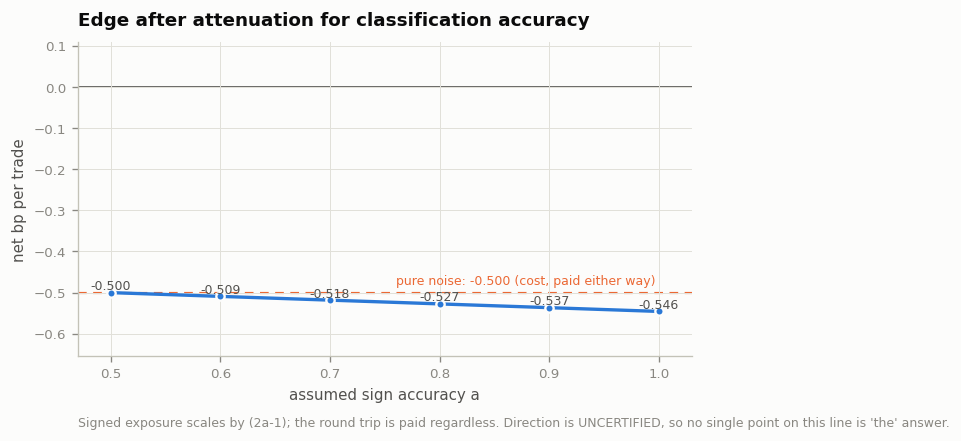

In [10]:
prim = verdicts[verdicts["gate"].astype(str).str.startswith("G4-primary")] if len(verdicts) else pd.DataFrame()
if len(prim):
    display(prim[[c for c in ("gate", "pass", "headline") if c in prim.columns]])
net = load("g5_net_table", index_col=0)
if len(net):
    print("-- gross, net of costs, and the attenuation grid")
    display(net)
    def _m(name):
        r = net[net["measure"] == name]
        return float(r["mean_bp"].iloc[0]) if len(r) else float("nan")

    # GROSS and cost separately: the (2a-1) haircut applies to the edge, not to the
    # round trip, which is paid whether or not the direction label was right.
    gross, cost_row = _m("gross"), _m("round-trip cost")
    if gross == gross:
        plots.attenuation_curve(gross, abs(cost_row) if cost_row == cost_row else 0.0)

bench = load("g4_directional_benchmark_is", index_col=0)
if len(bench):
    print("-- the SAME trades with the position held constant")
    display(bench)
    got = dict(zip(bench["variant"], bench["mean_bp"]))
    traded = got.get("as traded")
    best_const = max(got.get("always long rates (+1)", float("-inf")),
                     got.get("always short rates (-1)", float("-inf")))
    if traded is not None:
        print(f"  as traded {traded:+.4f}bp vs best constant {best_const:+.4f}bp")
        if traded <= best_const:
            print("  -> the rule does NOT beat pure direction: the ladder is contributing "
                  "nothing beyond it, whatever the t-statistic says")
        else:
            print("  -> the rule beats the better constant, so the signal is doing "
                  "something direction alone does not")

lock_bench = load("g4_directional_benchmark_lockout", index_col=0)
if len(lock_bench):
    print("-- and the same comparison on the LOCKOUT segment")
    display(lock_bench)


### Staleness sensitivity — how much of that number is carried-forward price?

The target rides a per-session minute grid with a **capped forward-fill**, because SR3
deferred contracts and ZQ trade in bursts rather than every minute. So a nominal
60-minute horizon can be a 35-minute price move with 25 minutes of flat carry at one
end. The pre-registration fixed **no** staleness cap, so the primary above runs
uncapped and this table is reported beside it rather than substituted for it.

The direction of the bias is knowable in advance: carry pulls a measured move toward
**zero**. So an effect that *strengthens* as the cap tightens was being diluted, and
one that *vanishes* was living in the carry. The sample panel is the guard against
over-reading the right-hand edge — at a 0-minute cap only the busiest
contract-minutes survive, which is a different population, not just a cleaner one.

,max_stale_min,n_trades,n_sessions,gross_bp,net_bp,t,stars,mean_realised_horizon_min,share_of_uncapped_trades
0,none,1639,99,-0.045760,-0.545760,-9.443265,***,59.568029,1.000000
1,30,1639,99,-0.045760,-0.545760,-9.443265,***,59.568029,1.000000
2,15,1639,99,-0.045760,-0.545760,-9.443265,***,59.568029,1.000000
3,10,1639,99,-0.046065,-0.546065,-9.452420,***,59.574741,1.000000
4,5,1639,99,-0.045149,-0.545149,-9.435396,***,59.621721,1.000000
5,2,1633,99,-0.048377,-0.548377,-9.436055,***,59.736681,0.996339
6,0,1578,98,-0.059569,-0.559569,-9.351310,***,60.000000,0.962782



  uncapped net -0.5458bp (t=-9.44, n=1639)
  tightest cap with a usable sample: 0min → net -0.5596bp (t=-9.35, n=1578)
  mean realised horizon uncapped: 59.6 of 60 nominal minutes


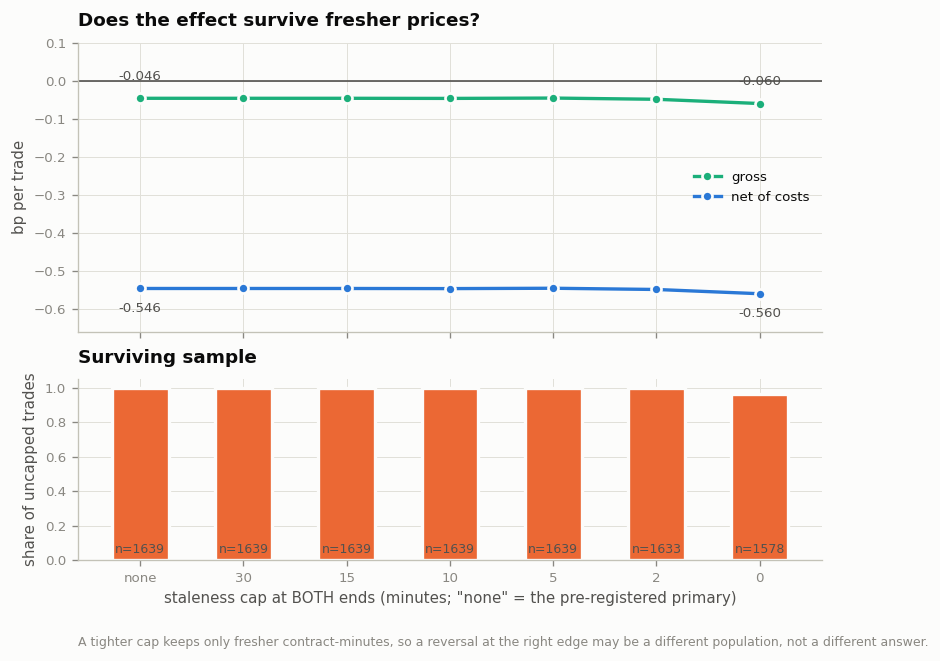

In [11]:
stale = load("g4_staleness_sensitivity", index_col=0)
if len(stale):
    display(stale)
    plots.staleness_panels(stale)
    tight = stale[stale["n_trades"] >= max(30, 0.1 * stale["n_trades"].iloc[0])]
    if len(tight) > 1:
        first, last = tight.iloc[0], tight.iloc[-1]
        print(f"\n  uncapped net {first['net_bp']:+.4f}bp (t={first['t']:.2f}, "
              f"n={int(first['n_trades'])})")
        print(f"  tightest cap with a usable sample: {last['max_stale_min']}min → "
              f"net {last['net_bp']:+.4f}bp (t={last['t']:.2f}, "
              f"n={int(last['n_trades'])})")
        print(f"  mean realised horizon uncapped: "
              f"{first['mean_realised_horizon_min']:.1f} of "
              f"{first.get('nominal_horizon_min', 60):.0f} nominal minutes")

### Secondary family — the WHOLE grid, winners and losers

Judged by day-blocked Romano-Wolf, resampling whole sessions jointly across variants so the
bootstrap null keeps cross-variant correlation. Reported with **best-config and median-config**
rows: a league table showing only the winner is a maximum statistic presented as a draw.

-- best-config vs median-config (the anti-selection control)


,role,variant,mean,se,t,n,n_blocks,lo,hi,n_boot,stars,hit_rate,share_long,share_agreeing,p_sign
0,best-config,FUTURES->FUTURES|hl1440|expected|h1440,-0.610197,0.553515,-1.102405,304,74,-1.638625,0.538808,200,NaN,0.457237,0.062500,0.527027,7.275471e-01
1,median-config,FUTURES->FUTURES|hl30|expected|h15,-0.482174,0.018430,-26.163109,4586,99,-0.523249,-0.447179,200,***,0.158962,0.344309,0.949495,2.380761e-22


-- full grid: 96 variants


,variant,mean,se,t,n,n_blocks,lo,hi,n_boot,stars,hit_rate,share_long,share_agreeing,p_sign
41,FUTURES->FUTURES|hl1440|expected|h1440,-0.610197,0.553515,-1.102405,304,74,-1.638625,0.538808,200,NaN,0.457237,0.062500,0.527027,0.727547
5,FUTURES->FUTURES|hl30|expected|h1440,-0.426667,0.374059,-1.140639,375,78,-1.235679,0.283968,200,NaN,0.416000,0.381333,0.551282,0.428207
47,FUTURES->FUTURES|hl1440|unweighted|h1440,-0.690789,0.550943,-1.253831,304,76,-1.652063,0.313398,200,NaN,0.460526,0.069079,0.500000,1.000000
11,FUTURES->FUTURES|hl30|unweighted|h1440,-0.518667,0.398603,-1.301212,375,78,-1.302047,0.227622,200,NaN,0.426667,0.362667,0.564103,0.308168
23,FUTURES->FUTURES|hl90|unweighted|h1440,-0.692521,0.353270,-1.960315,361,78,-1.357659,-0.000488,200,*,0.407202,0.290859,0.589744,0.140538
28,FUTURES->FUTURES|hl240|expected|h240,-0.521941,0.251703,-2.073637,376,95,-1.036927,-0.149823,200,*,0.369681,0.204787,0.642105,0.007313
29,FUTURES->FUTURES|hl240|expected|h1440,-0.884164,0.375120,-2.357014,341,77,-1.671674,-0.297776,200,*,0.410557,0.193548,0.597403,0.110016
35,FUTURES->FUTURES|hl240|unweighted|h1440,-0.857558,0.360372,-2.379648,344,77,-1.631412,-0.331209,200,*,0.404070,0.203488,0.597403,0.110016
40,FUTURES->FUTURES|hl1440|expected|h240,-0.691129,0.283473,-2.438081,310,85,-1.218028,-0.198355,200,*,0.296774,0.070968,0.635294,0.016509
17,FUTURES->FUTURES|hl90|expected|h1440,-0.824230,0.336460,-2.449710,357,77,-1.529368,-0.256939,200,*,0.403361,0.263305,0.584416,0.171061


-- Romano-Wolf family-wise adjusted p (day-blocked)


,mean,se,t,n,n_blocks,p_raw,p_fwer
FED_FUNDS->FED_FUNDS|hl240|unweighted|h5,-0.500410,0.001611,-310.657979,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl30|unweighted|h5,-0.500401,0.002170,-230.586429,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl30|expected|h5,-0.500685,0.002548,-196.492389,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl90|unweighted|h5,-0.503472,0.002658,-189.451035,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl1440|unweighted|h5,-0.495459,0.005226,-94.812738,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl1440|expected|h5,-0.494920,0.005252,-94.237911,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl240|expected|h5,-0.496070,0.005306,-93.497195,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl90|expected|h5,-0.497427,0.005611,-88.644490,99,99,0.0005,0.0005
FUTURES->FUTURES|hl90|expected|h5,-0.502719,0.005848,-85.962517,99,99,0.0005,0.0005
FED_FUNDS->FED_FUNDS|hl240|unweighted|h15,-0.506117,0.006401,-79.064842,99,99,0.0005,0.0005



  variants surviving FWER < 0.05: 83 of 96


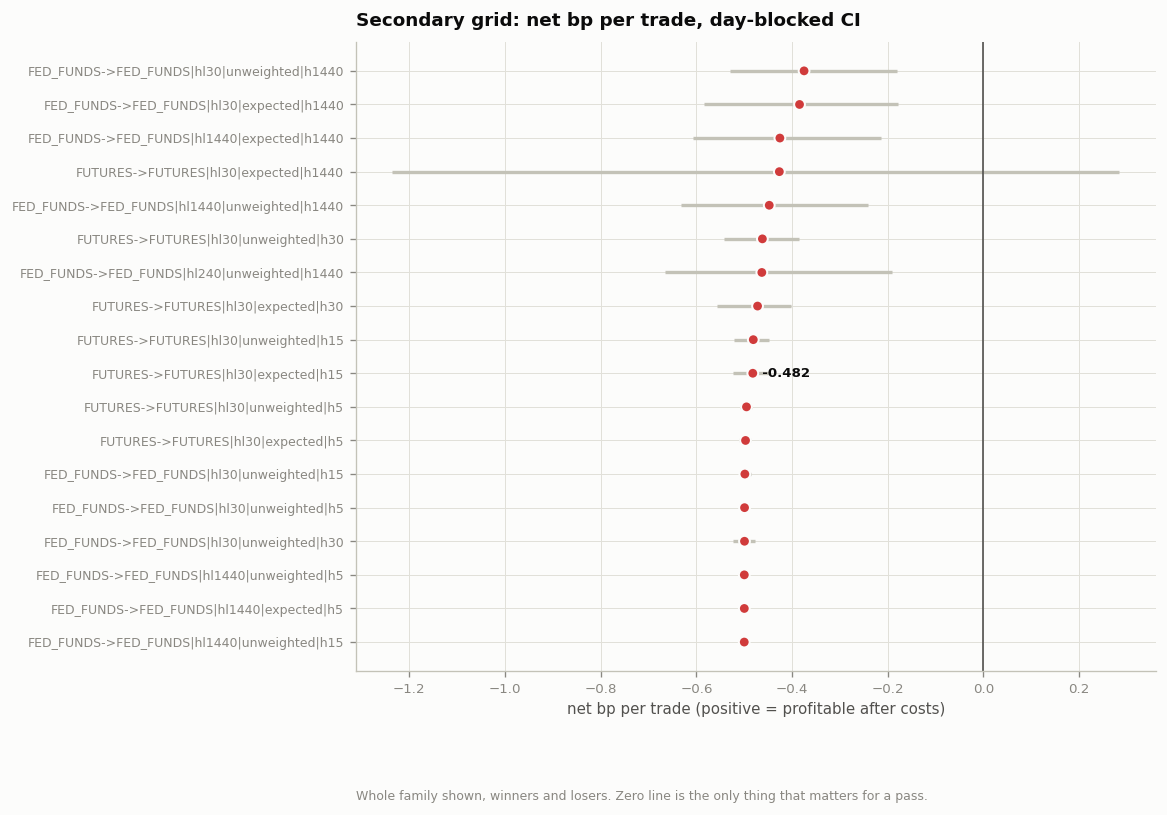

In [12]:
league = load("g4_league", index_col=0)
bm = load("g4_best_and_median", index_col=0)
rw = load("g4_romano_wolf", index_col=0)
if len(bm):
    print("-- best-config vs median-config (the anti-selection control)")
    display(bm)
if len(league):
    print(f"-- full grid: {len(league)} variants")
    display(league.sort_values("t", ascending=False).head(15))
    # The round-trip cost, read from the artifact rather than hardcoded, so the plot
    # marks where a ZERO GROSS edge falls. Every variant sitting on that line is the
    # whole story of this grid: the -0.5 is what you pay, not what you predicted.
    _net = load("g5_net_table")
    _cost = None
    if len(_net) and "measure" in _net.columns:
        _row = _net[_net["measure"].astype(str).str.contains("cost", case=False)]
        if len(_row):
            _cost = abs(float(_row["mean_bp"].iloc[0]))
    plots.league_dotplot(league, highlight=set(bm["variant"]) if len(bm) else (),
                         cost_bp=_cost)
if len(rw):
    print("-- Romano-Wolf family-wise adjusted p (day-blocked)")
    display(rw.head(20))
    n_sig = int((rw["p_fwer"] < 0.05).sum())
    print(f"\n  variants surviving FWER < 0.05: {n_sig} of {len(rw)}")

#### Variants that could NOT run

A grid row that produced no result is not a variant that was tested and found weak,
and the two must never look alike. Every declared combination that could not run is
listed here with its reason — chiefly that `MEETING` is model-internal bookkeeping
and so is never built as a test target, and that cross-space pairs have disjoint
bucket namespaces (an SR3 ladder cannot join a ZQ rate panel).

In [13]:
skipped = load("g4_skipped_variants", index_col=0)
if len(skipped):
    n_ran = len(league) if len(league) else 0
    print(f"{n_ran} variants ran, {len(skipped)} declared variants could not run")
    display(skipped.groupby("reason").size().rename("variants").to_frame())
    display(skipped.head(12))
else:
    print("every declared variant ran")

96 variants ran, 192 declared variants could not run


,variants
reason,
no shared bucket keys between signal and target space,96
signal space MEETING not built for this window,96


,variant,reason
0,FED_FUNDS->FUTURES|hl30|expected|h5,no shared bucket keys between signal and targe...
1,FED_FUNDS->FUTURES|hl30|expected|h15,no shared bucket keys between signal and targe...
2,FED_FUNDS->FUTURES|hl30|expected|h30,no shared bucket keys between signal and targe...
3,FED_FUNDS->FUTURES|hl30|expected|h60,no shared bucket keys between signal and targe...
4,FED_FUNDS->FUTURES|hl30|expected|h240,no shared bucket keys between signal and targe...
5,FED_FUNDS->FUTURES|hl30|expected|h1440,no shared bucket keys between signal and targe...
6,FED_FUNDS->FUTURES|hl30|unweighted|h5,no shared bucket keys between signal and targe...
7,FED_FUNDS->FUTURES|hl30|unweighted|h15,no shared bucket keys between signal and targe...
8,FED_FUNDS->FUTURES|hl30|unweighted|h30,no shared bucket keys between signal and targe...
9,FED_FUNDS->FUTURES|hl30|unweighted|h60,no shared bucket keys between signal and targe...


### Placebos

Each was specified in advance together with what its firing would mean. A placebo landing near
the reference is a **failure of the test**, not a success of the signal.

,placebo,expect,mean,t,stars,n,n_blocks,hit_rate,share_long
0,none (reference),"the effect, if any",-0.545760,-9.443265,***,1639,99,0.235509,0.276998
1,sign shuffle within session,destroyed; survival means intensity not direction,-0.447586,-11.219872,***,1636,99,0.256724,0.400367
2,arrival +1 grid step later,largely preserved; loss means knife-edge timing,-0.536585,-9.713677,***,1640,99,0.239634,0.278659
3,live parity (visibility floored at exec+15m),"attenuated, same sign",-0.540495,-9.094948,***,1636,98,0.234108,0.276284
4,rotated buckets,~0; survival means generic curve continuation,-0.519982,-9.334668,***,1639,99,0.218426,0.276998
5,pre-arrival window,~0; a result means leakage or anticipation,-0.458159,-6.232290,***,1434,97,0.250349,0.273361



  position balance -- reference 28% long-rates vs sign-shuffle 40%.
  The shuffle removes the PAID skew as well as the direction signal, so part of
  any gap is position balance rather than lost information.


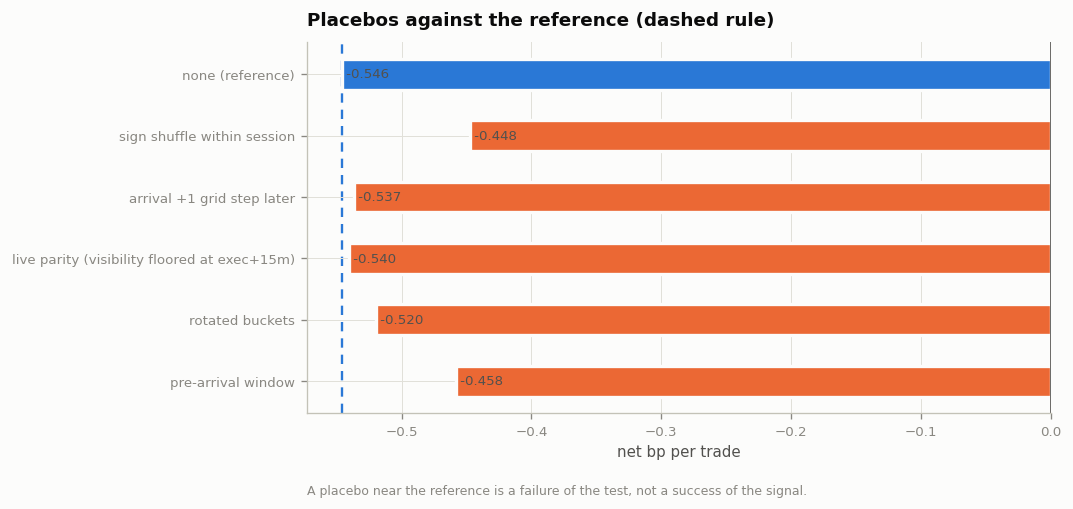

In [14]:
plac = load("g4_placebos", index_col=0)
if len(plac):
    display(plac[[c for c in ("placebo", "expect", "mean", "t", "stars", "n",
                              "n_blocks", "hit_rate", "share_long")
                  if c in plac.columns]])
    if "share_long" in plac.columns and plac["share_long"].notna().any():
        ref = plac[plac["placebo"].astype(str).str.startswith("none")]
        shuf = plac[plac["placebo"].astype(str).str.contains("shuffle")]
        if len(ref) and len(shuf):
            print(f"\n  position balance -- reference {ref['share_long'].iloc[0]:.0%} "
                  f"long-rates vs sign-shuffle {shuf['share_long'].iloc[0]:.0%}.")
            print("  The shuffle removes the PAID skew as well as the direction signal, "
                  "so part of\n  any gap is position balance rather than lost "
                  "information.")
    plots.placebo_panel(plac)

## G5 — economics and capacity

Capacity is a **depth** question and this repo has no historical depth or top-of-book data, so
what follows is a traded-**volume** sensitivity and is labelled that way in its own output. It is
an upper bound on what depth would allow, not a capacity claim.

In [15]:
cap = load("g5_capacity", index_col=0)
if len(cap):
    display(cap)

,participation,median_dv01_per_trade,total_dv01,n_trades_priced,n_trades_dropped,basis
0,0.01,4274.5,9401895.5,1639,0,"traded-volume sensitivity over (entry, exit], ..."
1,0.05,21372.5,47009477.5,1639,0,"traded-volume sensitivity over (entry, exit], ..."
2,0.10,42745.0,94018955.0,1639,0,"traded-volume sensitivity over (entry, exit], ..."


### G3b — does it also survive a basis our own curve did not produce?

Our basis control is built from the very curve that produced the signal, so on its own it
cannot separate "the ladder forecasts" from "our curve was mispriced against the futures
strip and both reverted". This second race adds a basis measured against the **Citi Velocity
swap-quote curve**. Run separately because the two bases are highly collinear — folding them
into one regression would inflate both standard errors and confound two different questions.
SR3 only: both independent sources are SOFR curves, so there is no independent ZQ basis.

In [16]:
indep = load("g3_horse_race_independent_FUTURES", index_col=0)
if len(indep):
    display(indep)
    sig = indep[(indep["spec"] == "signal + controls") & (indep["term"] == "signal")]
    if len(sig):
        print(f"  ladder t beside the INDEPENDENT basis: {float(sig['t'].iloc[0]):+.2f}")

,spec,term,coef,se,t,n,n_blocks,design_rank,design_cols,design_cond,rank_deficient
0,signal only,const,1.823151e-02,4.894356e-02,0.372501,38436,99,2,2,1.335265e+00,False
1,signal only,signal,1.328283e-02,2.650455e-02,0.501153,38436,99,2,2,1.335265e+00,False
2,signal + controls,const,2.304886e+01,1.747556e+01,1.318920,38436,99,16,16,2.914027e+08,False
3,signal + controls,signal,2.330875e-02,2.785415e-02,0.836814,38436,99,16,16,2.914027e+08,False
4,signal + controls,basis_bp,1.950070e-02,2.756278e-02,0.707501,38436,99,16,16,2.914027e+08,False
5,signal + controls,abs_basis_bp,1.493609e-03,2.638184e-02,0.056615,38436,99,16,16,2.914027e+08,False
6,signal + controls,signed_basis_dv01,1.729998e-07,1.914631e-07,0.903567,38436,99,16,16,2.914027e+08,False
7,signal + controls,level_bp,-6.214374e-02,4.769130e-02,-1.303041,38436,99,16,16,2.914027e+08,False
8,signal + controls,slope_bp,3.268044e-02,2.498902e-02,1.307792,38436,99,16,16,2.914027e+08,False
9,signal + controls,curvature_bp,2.704820e-02,1.867434e-02,1.448415,38436,99,16,16,2.914027e+08,False


  ladder t beside the INDEPENDENT basis: +0.84


#### Were the controls actually point-in-time?

The decision curve is calibrated from Barchart bars chosen with `method="nearest"` and
then forward/back-filled, so a request for a minute the vendor did not cover can
resolve against a bar from **after** it. The no-lookahead battery in G1 cannot see
this: it poisons the *ladder*, and this path feeds the *controls*. A control carrying
future information breaks the horse race in either direction — it can absorb variance
the signal should have explained, or manufacture a basis reversal that reads as "the
signal was really trading curve-fit error".

So the builder checks each minute against the curve handle's own stamp and drops the
ones stamped later than the decision. What it dropped is reported here, because a
control panel thinned by that check is a limitation on this gate's power.

In [17]:
pit = load("g3_point_in_time_FUTURES", index_col=0)
if len(pit):
    display(pit)
    for _, r in pit.iterrows():
        print(f"  {r['curve']}: dropped {int(r['rows_dropped_future_stamp'])} minutes "
              f"({r['drop_rate']:.2%}) for a curve stamped AFTER the decision; "
              f"{int(r['rows_unverifiable_stamp'])} ({r['unverifiable_rate']:.2%}) "
              f"could not be verified either way")
else:
    print("no point-in-time report — G3 did not run, or the pricer exposes no stamp")

,curve,rows_dropped_future_stamp,drop_rate,rows_unverifiable_stamp,unverifiable_rate
0,decision_curve,0.0,0.0,0.0,0.0
1,independent_curve,0.0,0.0,0.0,0.0


  decision_curve: dropped 0 minutes (0.00%) for a curve stamped AFTER the decision; 0 (0.00%) could not be verified either way
  independent_curve: dropped 0 minutes (0.00%) for a curve stamped AFTER the decision; 0 (0.00%) could not be verified either way


### The label-free cell

The identical rule driven by **unsigned print intensity** — `|delta_dv01|`, direction
ignored — so it is immune to classification accuracy. The comparison is the point. If the
signed ladder works and this does not, direction is carrying the result. If both work
similarly, the finding is a flow-**activity** effect, the direction model is carrying
nothing, and no attenuation grid rescues that.

In [18]:
lf = load("g4_label_free", index_col=0)
if len(lf):
    display(lf)

,mean,se,t,n,n_blocks,lo,hi,n_boot,stars,hit_rate,share_long,share_agreeing,p_sign,signal
0,-0.640234,0.070866,-9.034434,1838,99,-0.778519,-0.50187,2000,***,0.237758,0.49728,0.848485,8.222851e-13,unsigned print intensity


### Conditioning splits

Terciles of block share, proximity to the 25bp policy grid, realised vol, Amihud, the
SOFR−EFFR funding spread, days to FOMC and time of day. Terciles rather than interaction
terms: at ~150 independent epochs an interaction is not identified, while *does the sign hold
in all three buckets* is answerable — and the audit asks to **segment**, not merely control.

In [19]:
cond = load("g4_conditioning", index_col=0)
if len(cond):
    display(cond)
    consistent = cond.groupby("conditioner")["mean_net_bp"].apply(
        lambda x: bool((x > 0).all() or (x < 0).all()))
    print("\n  sign-consistent across terciles:")
    for k, v in consistent.items():
        print(f"    {'yes' if v else 'NO '}  {k}")

skipped_cond = load("g4_conditioning_skipped", index_col=0)
if len(skipped_cond):
    print("-- conditioners that could NOT be split (a split that vanished is not a null)")
    display(skipped_cond)


,conditioner,bucket,n,n_blocks,mean_net_bp,t,stars,median_value
0,block_share,q1,546,59,-0.374542,-5.488011,***,1.237679e-08
1,block_share,q2,546,68,-0.666667,-9.437041,***,2.462783e-02
2,block_share,q3,547,59,-0.595978,-4.650757,***,2.580272e-01
3,level_prox_bp,q1,546,86,-0.569597,-8.089544,***,-9.055701e+00
4,level_prox_bp,q2,546,88,-0.599817,-7.985474,***,-1.347494e+00
5,level_prox_bp,q3,547,88,-0.468007,-5.906159,***,7.466569e+00
6,realized_vol_bp,q1,477,88,-0.460692,-10.133639,***,2.574643e-01
7,realized_vol_bp,q2,477,90,-0.589099,-7.492817,***,3.964807e-01
8,realized_vol_bp,q3,477,78,-0.415094,-3.387410,***,6.336522e-01
9,amihud,q1,477,83,-0.484277,-10.416179,***,7.205026e-05



  sign-consistent across terciles:
    yes  amihud
    yes  block_share
    yes  days_to_fomc
    yes  level_prox_bp
    yes  realized_vol_bp
    yes  tod_min
-- conditioners that could NOT be split (a split that vanished is not a null)


,conditioner,reason
0,sofr_effr_bp,panel not built for this space


### G0 detail — mid offset, and flips by stratum

The offset table is the gate's real payload: our spread-to-mid minus the independent one
**is** (independent mid − our mid), so its systematic sign says which curve sits above the
other, and `share_offset_gt_quarter_bp` says how often that gap exceeds the half-spread the
direction rule is trying to read.

In [20]:
for name in ("g0_mid_offset_bps", "g0_flip_by_curve_bucket", "g0_flip_by_hour",
             "g0_skew_vs_independent_by_hour"):
    frame = load(name, index_col=0)
    if len(frame):
        print(f"-- {name}")
        display(frame)

acc = load("g0_implied_accuracy", index_col=0)
if len(acc):
    print("-- implied bounds on direction accuracy")
    display(acc)


-- g0_mid_offset_bps


,stratum,n,mean_our_s2m_bps,mean_ind_s2m_bps,mean_offset_bps,median_offset_bps,share_offset_gt_quarter_bp
0,ALL,4723,27.602263,29.551862,-1.949600,-0.356053,0.700191
1,CURVE_CLEAN,2982,-0.758688,-0.155946,-0.602742,-0.261501,0.621395
2,CURVE_SUSPECT,1741,76.179147,80.435657,-4.256510,-1.127537,0.835152


-- g0_flip_by_curve_bucket


,curve_bucket,n_units,n_compared,flip_rate,n_no_coverage
0,CURVE_CLEAN,3506,2982,0.397720,524
1,CURVE_SUSPECT,2014,1741,0.318782,273


-- g0_flip_by_hour


,hour,n_units,n_compared,flip_rate,n_no_coverage
0,0,167,0,NaN,167
1,1,187,181,0.447514,6
2,2,233,228,0.416667,5
3,3,240,234,0.371795,6
4,4,239,232,0.418103,7
5,5,222,215,0.446512,7
6,6,211,208,0.447115,3
7,7,256,251,0.402390,5
8,8,346,337,0.373887,9
9,9,383,373,0.402145,10


-- g0_skew_vs_independent_by_hour


,hour,n,our_paid_share,ind_paid_share,flip_rate
0,1,181.0,0.756906,0.508287,0.447514
1,2,228.0,0.833333,0.539474,0.416667
2,3,234.0,0.841880,0.572650,0.371795
3,4,232.0,0.827586,0.547414,0.418103
4,5,215.0,0.851163,0.516279,0.446512
5,6,208.0,0.798077,0.495192,0.447115
6,7,251.0,0.760956,0.581673,0.402390
7,8,337.0,0.824926,0.605341,0.373887
8,9,373.0,0.782842,0.536193,0.402145
9,10,366.0,0.803279,0.568306,0.327869


-- implied bounds on direction accuracy


,flip_rate,accuracy_ceiling,attenuation_at_ceiling
0,0.39772,0.80114,0.60228


#### Is a flip explained by the curve gap alone?

The direction label is nothing but which side of the mid a print landed on, so it should flip
exactly when the two curves differ by more than the print's own distance to mid. If that closed
form reproduces the observed flips, the disagreement is **not label noise to be averaged away** —
it is a mechanism, and it bites hardest precisely where the trade printed closest to mid.

**`false_negative` is the column to read.** A non-zero count is the interesting outcome: a flip the
curve gap does *not* account for, which would mean something other than curve disagreement is
moving the label.

In [21]:
mech = load("g0_flip_mechanism", index_col=0)
if len(mech):
    display(mech)
    allrow = mech[mech["stratum"] == "ALL"]
    if len(allrow):
        r = allrow.iloc[0]
        print(f"  agreement {r['agreement']:.1%} over n={int(r['n'])}: "
              f"{int(r['true_positive'])} flips predicted and observed, "
              f"{int(r['false_positive'])} false positives, "
              f"{int(r['false_negative'])} FALSE NEGATIVES")
        if r["false_negative"] == 0:
            print("  -> every observed flip is accounted for by the curve gap")
        else:
            print(f"  -> {int(r['false_negative'])} flips the curve gap does NOT explain "
                  f"-- something else is moving the label")

,stratum,n,flip_rate,predicted_rate,agreement,true_positive,false_positive,false_negative,true_negative,median_abs_s2m_bps,median_offset_bps
0,ALL,4723,0.368622,0.403134,0.965488,1741,163,0,2819,0.636988,-0.356053
1,"|s2m| (-0.001, 0.221]",945,0.422222,0.549206,0.873016,399,120,0,426,0.129108,-0.045856
2,"|s2m| (0.221, 0.435]",944,0.411017,0.441737,0.969280,388,29,0,527,0.317597,-0.241591
3,"|s2m| (0.435, 1.016]",945,0.362963,0.376720,0.986243,343,13,0,589,0.636988,-0.457819
4,"|s2m| (1.016, 5.762]",944,0.305085,0.306144,0.998941,288,1,0,655,1.532280,-1.105938
5,"|s2m| (5.762, 39597.669]",945,0.341799,0.341799,1.000000,323,0,0,622,12.957730,-7.782075


  agreement 96.5% over n=4723: 1741 flips predicted and observed, 163 false positives, 0 FALSE NEGATIVES
  -> every observed flip is accounted for by the curve gap


#### Is `p_flip` calibrated, and does the `expected` weighting do anything?

The ladder's `expected` weighting is `1 − 2·p_flip`, so a print believed likely to be mislabelled
is carried smaller. That only improves on `unweighted` if `p_flip` tracks disagreement.

Read **rank** and **level** separately — they fail differently and the difference decides what the
quantity can be used for. A `p_flip` that orders error correctly but is an order of magnitude too
small can rank prints; it cannot correct them. And if `mean_weight_agreeing` and
`mean_weight_flipped` are close, the weighting is not down-weighting the prints that actually
disagree, so `expected` and `unweighted` are the same trade scaled by a constant.

In [22]:
pf = load("g0_pflip_calibration", index_col=0)
if len(pf):
    display(pf)
    allrow = pf[pf["stratum"] == "ALL"]
    if len(allrow):
        r = allrow.iloc[0]
        print(f"  mean p_flip {r['mean_p_flip']:.4f} vs observed flip rate "
              f"{r['observed_flip']:.3f}  (gap {r['calibration_gap']:+.3f})")
        print(f"  rank agreement (spearman) {r['spearman_rank']:+.3f}")
        sep = r["mean_weight_agreeing"] - r["mean_weight_flipped"]
        print(f"  weight on agreeing {r['mean_weight_agreeing']:.3f} vs flipped "
              f"{r['mean_weight_flipped']:.3f}  (separation {sep:+.3f})")
        if abs(sep) < 0.05:
            print("  -> the weighting barely separates them: `expected` is ~`unweighted` "
                  "scaled by a constant, not a correction for label error")

,stratum,n,mean_p_flip,observed_flip,calibration_gap,spearman_rank,mean_weight,mean_weight_agreeing,mean_weight_flipped
0,ALL,2732,4.534620e-02,0.400439,0.355093,0.063466,0.909308,0.916539,0.89848
1,"p_flip (-0.001, 3.17e-13]",547,4.989712e-15,0.369287,0.369287,NaN,1.000000,NaN,NaN
2,"p_flip (3.17e-13, 0.000158]",546,2.079130e-05,0.357143,0.357122,NaN,0.999958,NaN,NaN
3,"p_flip (0.000158, 0.00896]",546,2.460725e-03,0.404762,0.402301,NaN,0.995079,NaN,NaN
4,"p_flip (0.00896, 0.0812]",546,3.469895e-02,0.417582,0.382883,NaN,0.930602,NaN,NaN
5,"p_flip (0.0812, 0.452]",547,1.893698e-01,0.453382,0.264012,NaN,0.621260,NaN,NaN


  mean p_flip 0.0453 vs observed flip rate 0.400  (gap +0.355)
  rank agreement (spearman) +0.063
  weight on agreeing 0.917 vs flipped 0.898  (separation +0.018)
  -> the weighting barely separates them: `expected` is ~`unweighted` scaled by a constant, not a correction for label error


## Trial ledger

Every configuration evaluated, in order, including discarded ones. A family-wise correction is
only honest if the family is the one actually searched.

In [23]:
tl = load("trial_ledger", index_col=0)
if len(tl):
    print(f"{len(tl)} trials recorded")
    display(tl)

98 trials recorded


,label,cfg_horizon,cfg_threshold,res_mean,res_t,note,cfg_signal,cfg_signal_space,cfg_target,cfg_half_life,cfg_weighting
trial,,,,,,,,,,,
1,PRIMARY (in-sample),60,1.0,-0.545760,-9.443265,NaN,NaN,NaN,NaN,NaN,NaN
2,"LABEL-FREE (unsigned intensity, FUTURES)",60,1.0,-0.640234,-9.034434,NaN,intensity,NaN,NaN,NaN,NaN
3,FUTURES->FUTURES|hl30|expected|h5,5,NaN,-0.497341,-76.842836,NaN,NaN,FUTURES,FUTURES,30.0,expected
4,FUTURES->FUTURES|hl30|expected|h15,15,NaN,-0.482174,-26.163109,NaN,NaN,FUTURES,FUTURES,30.0,expected
5,FUTURES->FUTURES|hl30|expected|h30,30,NaN,-0.472212,-12.700049,NaN,NaN,FUTURES,FUTURES,30.0,expected
6,FUTURES->FUTURES|hl30|expected|h60,60,NaN,-0.504605,-7.267834,NaN,NaN,FUTURES,FUTURES,30.0,expected
7,FUTURES->FUTURES|hl30|expected|h240,240,NaN,-0.542262,-2.790210,NaN,NaN,FUTURES,FUTURES,30.0,expected
8,FUTURES->FUTURES|hl30|expected|h1440,1440,NaN,-0.426667,-1.140639,NaN,NaN,FUTURES,FUTURES,30.0,expected
9,FUTURES->FUTURES|hl30|unweighted|h5,5,NaN,-0.495347,-74.742989,NaN,NaN,FUTURES,FUTURES,30.0,unweighted
